import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Goal  

The goal of this lab is to measure the surface resistivity of conductive paper by analyzing voltage and current relationships. By performing multiple experiments and addressing challenges in electrical connections, we aim to obtain a reliable estimate of R_s and compare it to known reference values.


## Procedure  

1. Set up a circuit using a constant current source to apply current across the conductive paper.  
2. Use a Voltmeter to measure the potential difference along the sample.  
3. Ensure reliable electrical connections using conductive push pins.  
4. Perform at least two different experiments to measure R_s  in multiple ways.  
5. Use Ohm’s law and the surface resistivity model to determine R_s .  
6. Compare the measured values to the PASCO reference resistivity 5,000 Ω/sq.  


## Getting the first set of measured data

In [127]:
data1 = pd.read_excel("data/data1.xlsx")
data1

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V)
0,0.16,0.005,0.0694,0.005,3.57
1,0.15,0.005,0.0694,0.005,3.39
2,0.14,0.005,0.0694,0.005,3.00
3,0.13,0.005,0.0694,0.005,2.79
4,0.12,0.005,0.0694,0.005,2.52
5,0.11,0.005,0.0694,0.005,2.46
6,0.10,0.005,0.0694,0.005,2.23
7,0.09,0.005,0.0694,0.005,1.99
8,0.08,0.005,0.0694,0.005,1.74
9,0.07,0.005,0.0694,0.005,1.52


#### Looking at the manual of our LCM meter the uncertainity for voltages is given by 0.8% of the data + 1 digit

In [130]:
volt_uncertainity = lambda x: 0.8e-2  * x + 0.001
data1["d_Voltage (V)"] = data1["Voltage (V)"].apply(volt_uncertainity)
data1.head()

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V),d_Voltage (V)
0,0.16,0.005,0.0694,0.005,3.57,0.02956
1,0.15,0.005,0.0694,0.005,3.39,0.02812
2,0.14,0.005,0.0694,0.005,3.00,0.02500
3,0.13,0.005,0.0694,0.005,2.79,0.02332
4,0.12,0.005,0.0694,0.005,2.52,0.02116


#### For our measurment we have applied a constant rate of dirrect current.

In [133]:
current = 215e-6
d_current = 5e-6

### Measured Current  

The applied current, including uncertainty, is:  

$$
I = (220 \pm 5) \times 10^{-6} \, \text{A}
$$

where I represents the applied current in **amperes (A)**.


#### Calculating Resistance at Each Distance Iteration  

We will calculate the resistance for each iteration of distance using **Ohm’s law**:  

$$
R = \frac{V}{I}
$$

where **R** is the resistance, **V** is the measured voltage, and **I** is the applied current.


In [273]:
# set up the resistance columb via the formula voltage / current (Ohms law)
data1["Resistance (Ohms)"] = data1["Voltage (V)"] / current

### Error Propagation for Division

For $ Q = \frac{A}{B} $ with uncertainties $ \Delta A $ and $ \Delta B $, the propagated error is:

$$
\frac{\Delta Q}{Q} = \sqrt{\left(\frac{\Delta A}{A}\right)^2 + \left(\frac{\Delta B}{B}\right)^2}
$$

$$
\Delta Q = Q \times \sqrt{\left(\frac{\Delta A}{A}\right)^2 + \left(\frac{\Delta B}{B}\right)^2}
$$


## Dominant source of Uncertainity

#### The primary source of uncertainty in this experiment was the fluctuation of the voltmeter readings, making it difficult to obtain precise voltage values. In fact, we often had to rely on a best estimate of what we believed to be the actual value.

In [280]:
# formula for error popagation

def div_err_propagaton(Q=None, A=None, B=None, d_A=None, d_B=None):
    assert A != None and B != None and Q != None and d_A != None and d_B != None, "Missing parameters"
    """
    Function: 
        Propagates the error for the division of two terms (Assumes Numpy already imported)

    Parameters:
        Q: The quotient we are propagating the error for
        A: The Numerator
        B: The Denominator
        d_A: The error for the numerator
        d_B: The error for the denominator 

    Return Value:
        The propagated error
    """

    return Q * np.sqrt( (d_A / A)**2 +  (d_B / B)**2 )

#### Calculate the error propagation for the resistance 

In [283]:
data1["d_Resistance (Ohms)"] = data1.apply(lambda row: div_err_propagaton(row["Resistance (Ohms)"], row["Voltage (V)"], current, row["d_Voltage (V)"], d_current), axis=1)
data1.head()

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V),d_Voltage (V),Resistance (Ohms),d_Resistance (Ohms),Distance/Width (M),d_Distance/Width (M)
0,0.16,0.005,0.0694,0.005,3.57,0.02956,16604.651163,409.900583,2.305476,0.181053
1,0.15,0.005,0.0694,0.005,3.39,0.02812,15767.441860,389.312049,2.161383,0.171578
2,0.14,0.005,0.0694,0.005,3.00,0.02500,13953.488372,344.704071,2.017291,0.162215
3,0.13,0.005,0.0694,0.005,2.79,0.02332,12976.744186,320.684761,1.873199,0.152983
4,0.12,0.005,0.0694,0.005,2.52,0.02116,11720.930233,289.803303,1.729107,0.143909


### Since we already know the length and width of our conduction material and since we have already calculated the resistance, we can determine sheet resistance $ R_s $, which would be the slope of the line where:

- $ y $= resistance $ R $
- $ m = R_s $ (sheet resistance)
- $ x = \frac{length}{width} $

In [286]:
# create a new column for the length / width
data1["Distance/Width (M)"] = data1["Distance (M)"] / data1["Width (M)"]


# Get the error propagation for the distance / width 
data1["d_Distance/Width (M)"] = data1.apply(lambda row: div_err_propagaton(row["Distance/Width (M)"], row["Distance (M)"], row["Width (M)"], row["d_Distance (M)"], row["d_Width (M)"]), axis=1)


#### Now we are going to scatter our calculated resistance with the length/width to see if the scatter folllows a linear relationship


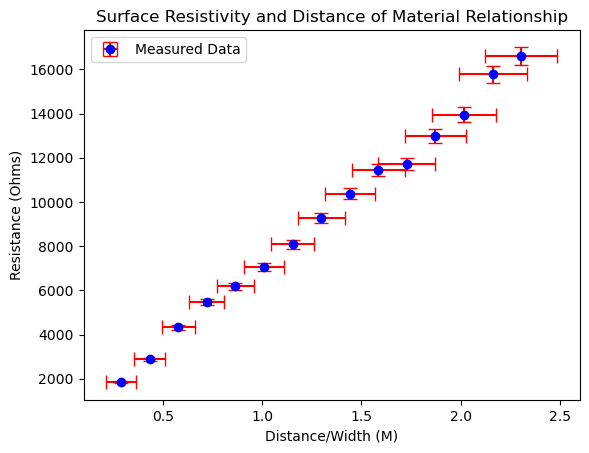

In [289]:
# Extracting x, y, and their uncertainties
x = data1["Distance/Width (M)"]
y = data1["Resistance (Ohms)"]
x_err = data1["d_Distance/Width (M)"]
y_err = data1["d_Resistance (Ohms)"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Distance/Width (M)")
plt.ylabel("Resistance (Ohms)")
plt.title("Surface Resistivity and Distance of Material Relationship")
plt.legend()
plt.show()


Here the slope of the line represents the Surace of resistivity of our Conducting material
### Now we are going to fit a regression line where we would use scipy.curve_fit to estimate the slope and its error. 

In [292]:
linear_model = lambda x, A, B: A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
print(f"{slope:.2e}, {intercept:.2e}")
errors

7.24e+03, -1.66e+02


array([[ 5629.45840213, -3196.11058557],
       [-3196.11058557,  2854.0954287 ]])

#### Surface resistivity of the conducting material
$$
R_s = (7.30 \pm 0.3 \times 10^3) \, \Omega
$$



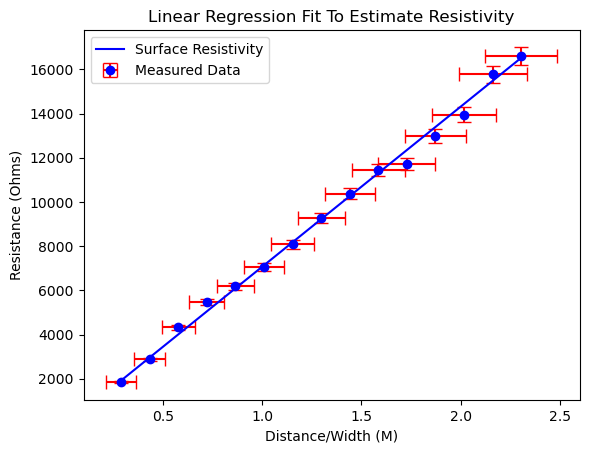

In [295]:
# Extracting x, y, and their uncertainties
x = data1["Distance/Width (M)"]
y = data1["Resistance (Ohms)"]
x_err = data1["d_Distance/Width (M)"]
y_err = data1["d_Resistance (Ohms)"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Distance/Width (M)")
plt.ylabel("Resistance (Ohms)")
plt.title("Linear Regression Fit To Estimate Resistivity")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Surface Resistivity", color='blue')

plt.legend(); 
plt.show()

# Now we are going to do the same thing again but for a conducting material of a different width to see if our results match. In theory they should

In [298]:
data2 = pd.read_excel("data/data2.xlsx")
data2

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V)
0,0.16,0.005,0.052,0.005,4.98
1,0.15,0.005,0.052,0.005,4.61
2,0.14,0.005,0.052,0.005,4.32
3,0.13,0.005,0.052,0.005,3.97
4,0.12,0.005,0.052,0.005,3.68
5,0.11,0.005,0.052,0.005,3.34
6,0.10,0.005,0.052,0.005,3.01
7,0.09,0.005,0.052,0.005,2.67
8,0.08,0.005,0.052,0.005,2.37
9,0.07,0.005,0.052,0.005,2.04


Getting the uncertainty for the voltage

In [301]:
volt_uncertainity = lambda x: 0.8e-2  * x + 0.001
data2["d_Voltage (V)"] = data2["Voltage (V)"].apply(volt_uncertainity)
data2.head()

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V),d_Voltage (V)
0,0.16,0.005,0.052,0.005,4.98,0.04084
1,0.15,0.005,0.052,0.005,4.61,0.03788
2,0.14,0.005,0.052,0.005,4.32,0.03556
3,0.13,0.005,0.052,0.005,3.97,0.03276
4,0.12,0.005,0.052,0.005,3.68,0.03044


In [303]:
# set up the resistance columb via the formula voltage / current (Ohms law)
data2["Resistance (Ohms)"] = data2["Voltage (V)"] / current

#### Get the error propagation for the resistance 

In [306]:
data2["d_Resistance (Ohms)"] = data2.apply(lambda row: div_err_propagaton(row["Resistance (Ohms)"], row["Voltage (V)"], current, row["d_Voltage (V)"], d_current), axis=1)
data2.head()

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V),d_Voltage (V),Resistance (Ohms),d_Resistance (Ohms)
0,0.16,0.005,0.052,0.005,4.98,0.04084,23162.790698,571.180543
1,0.15,0.005,0.052,0.005,4.61,0.03788,21441.860465,528.858458
2,0.14,0.005,0.052,0.005,4.32,0.03556,20093.023256,495.687256
3,0.13,0.005,0.052,0.005,3.97,0.03276,18465.116279,455.653284
4,0.12,0.005,0.052,0.005,3.68,0.03044,17116.279070,422.482525


In [308]:
# create a new column for the length / width
data2["Distance/Width (M)"] = data2["Distance (M)"] / data2["Width (M)"]


# Get the error propagation for the distance / width 
data2["d_Distance/Width (M)"] = data2.apply(lambda row: div_err_propagaton(row["Distance/Width (M)"], row["Distance (M)"], row["Width (M)"], row["d_Distance (M)"], row["d_Width (M)"]), axis=1)
data2.head()

,Distance (M),d_Distance (M),Width (M),d_Width (M),Voltage (V),d_Voltage (V),Resistance (Ohms),d_Resistance (Ohms),Distance/Width (M),d_Distance/Width (M)
0,0.16,0.005,0.052,0.005,4.98,0.04084,23162.790698,571.180543,3.076923,0.311091
1,0.15,0.005,0.052,0.005,4.61,0.03788,21441.860465,528.858458,2.884615,0.293561
2,0.14,0.005,0.052,0.005,4.32,0.03556,20093.023256,495.687256,2.692308,0.276156
3,0.13,0.005,0.052,0.005,3.97,0.03276,18465.116279,455.653284,2.500000,0.258902
4,0.12,0.005,0.052,0.005,3.68,0.03044,17116.279070,422.482525,2.307692,0.241831


#### Visualizing the relationship of the surface resistivity and distance for data 2

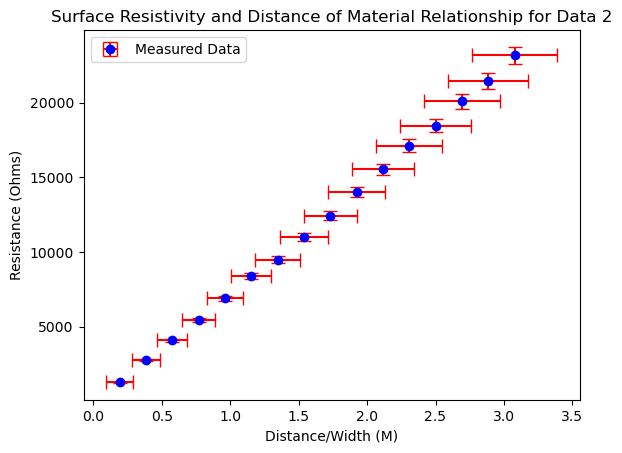

In [311]:
# Extracting x, y, and their uncertainties
x = data2["Distance/Width (M)"]
y = data2["Resistance (Ohms)"]
x_err = data2["d_Distance/Width (M)"]
y_err = data2["d_Resistance (Ohms)"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Distance/Width (M)")
plt.ylabel("Resistance (Ohms)")
plt.title("Surface Resistivity and Distance of Material Relationship for Data 2")
plt.legend()
plt.show()


In [313]:
def linear_model(x, A, B):
    return  A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
print(f"{slope:.2e}, {intercept:.2e}")
print(errors)

7.40e+03, -1.65e+02
[[ 3653.46954709 -1447.30422149]
 [-1447.30422149  1272.26159183]]


#### Surface resistivity of the conducting material
$$
R_s = (7.40 \pm 0.3 \times 10^3) \, \Omega
$$


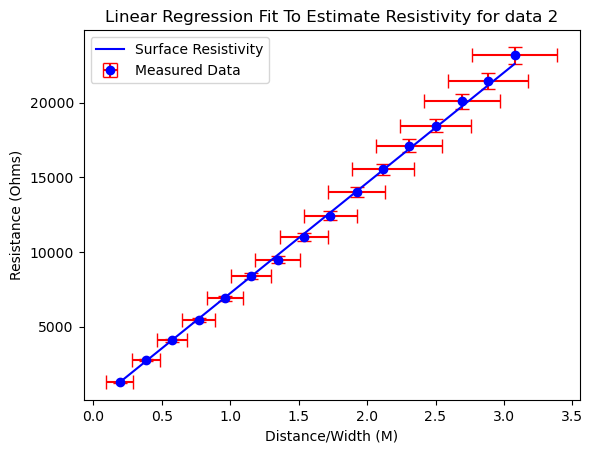

In [316]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Distance/Width (M)")
plt.ylabel("Resistance (Ohms)")
plt.title("Linear Regression Fit To Estimate Resistivity for data 2")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Surface Resistivity", color='blue')

plt.legend(); 
plt.show()

## Comparison to accepted value

In [323]:
# Get the measurments of the rest of the class
others = pd.read_excel("data/PathResistance_SharedData(Sheet1).xlsx")
others.head()
rs_values = others["Unnamed: 1"][2:]
rs_uncertainties = others["Unnamed: 2"][2:]

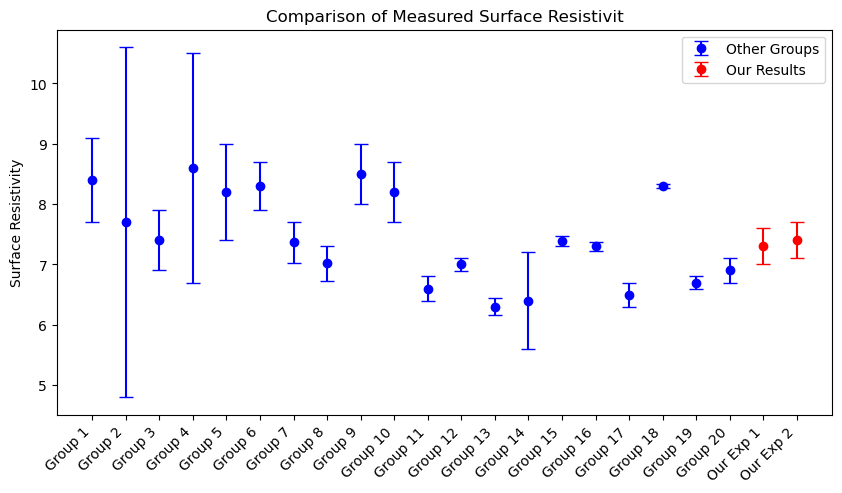

In [342]:
Rs_measured = [7.30, 7.40]  
d_Rs_measured = [0.3, 0.3]  # Uncertainty in measured sheet resistance

# Extract class data from the CSV dataset
Rs_other = rs_values  # Other groups' Rs values
d_Rs_other = rs_uncertainties  # Other groups' Rs uncertainties

# Create x-axis labels
x_labels = [f"Group {i+1}" for i in range(len(Rs_other))] + ["Our Exp 1", "Our Exp 2"]
x_positions = np.arange(len(x_labels))

# Generate comparison plot
plt.figure(figsize=(10, 5))
plt.errorbar(x_positions[:-2], Rs_other, yerr=d_Rs_other, fmt='o', label="Other Groups", color='blue', capsize=5)
plt.errorbar(x_positions[-2:], Rs_measured, yerr=d_Rs_measured, fmt='o', label="Our Results", color='red', capsize=5)

# Formatting the plot
plt.xticks(x_positions, x_labels, rotation=45, ha="right")
plt.ylabel("Surface Resistivity")
plt.title("Comparison of Measured Surface Resistivit")
plt.legend()


# Show the plot
plt.show()


## Connection to physics

#### In this lab, we determined the resistivity of conductive sheets by analyzing the slope of the linear relationship between resistance and distance. We confirmed that Ohm’s Law holds and is highly accurate in this context. Additionally, we observed that the dimensions of a conductor affect its resistance: longer conductors exhibit higher resistance, while wider conductors have lower resistance. This aligns with the theoretical relationship between resistance, length, and cross-sectional area in resistive materials.









## Apparatus Diagram

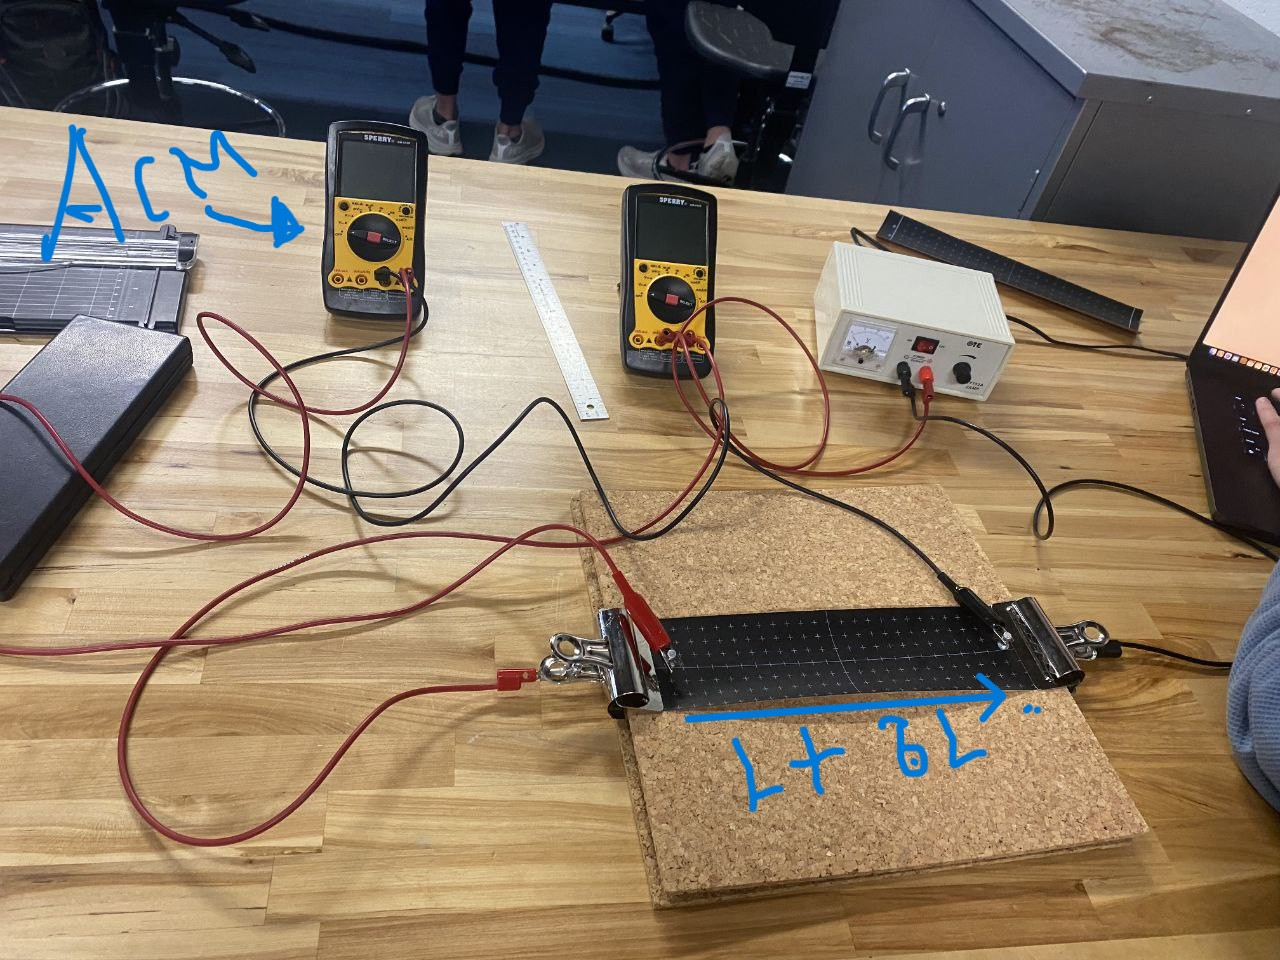